# CS5242 Project Report

**Team Members (Group 10):**
- Guo Bohao [A0117428E]
- Ma Yuanheng [A0329794J]
- Paul Gita Alekhya [A0328476R]
- Wang Yuwen [A0211193R]

## Table of Contents

1. [Introduction](#1-introduction)
2. [Datasets](#2-datasets)
   - 2.1 [MobileRec](#21-mobilerec)
     - 2.1.1 [Dataset Description](#211-dataset-description)
     - 2.1.2 [Exploratory Data Analysis](#212-exploratory-data-analysis)
     - 2.1.3 [Data Preprocessing](#213-data-preprocessing)
   - 2.2 [Steam](#22-steam-dataset)
     - 2.2.1 [Dataset Description](#221-dataset-description)
     - 2.2.2 [Collection Pipeline](#222-collection-pipeline)
     - 2.2.3 [Exploratory Data Analysis](#223-exploratory-data-analysis)
     - 2.2.4 [Data Preprocessing](#224-data-preprocessing)
3. [Methodology](#3-methodology)
   - 3.1 [Problem Formulation](#31-problem-formulation)
   - 3.2 [SASRec (Baseline)](#32-sasrec-baseline)
   - 3.3 [TiSASRec (Proposed)](#33-tisasrec-proposed)
4. [Experiments](#4-experiments)
   - 4.1 [Experimental Setup](#41-experimental-setup)
   - 4.2 [Results - MobileRec](#42-results--mobilerec)
   - 4.3 [Results - Steam](#43-results--steam)
   - 4.4 [Analysis & Discussion](#44-analysis--discussion)
5. [Conclusion](#5-conclusion)
6. [References](#references)

---
## 1. Introduction

The growth of mobile application ecosystems has made app discovery increasingly difficult, motivating personalised recommender systems. This project focuses on **sequential recommendation**: given a user's chronologically ordered interaction history $S_u = [i_1, i_2, \ldots, i_t]$, predict the next item $i_{t+1}$ they are most likely to engage with.

We study this task across two real-world datasets from distinct digital consumption domains -- **MobileRec** (Google Play app reviews) and **Steam** (PC game reviews) -- to assess both model effectiveness and cross-domain generalisability.

**SASRec** (Kang & McAuley, 2018) applies a unidirectional Transformer with causal self-attention to model item sequences and serves as our baseline. Despite its strong empirical track record, SASRec treats interactions as positionally ordered but temporally uniform, discarding timestamp information entirely.

**TiSASRec** (Li et al., 2020) extends SASRec by encoding time intervals between interactions directly into the attention mechanism. Because both MobileRec and Steam provide Unix timestamps for every review, TiSASRec is a natural fit: the central hypothesis is that *when* a user interacted is informative about *what* they will interact with next.

Both models are evaluated under the standard **leave-one-out** protocol using **HR@10** and **NDCG@10**.

---
## 2. Datasets

### 2.1 MobileRec

#### 2.1.1 Dataset Description

MobileRec is sourced from the Hugging Face Hub (`recmeapp/mobilerec`) and contains user reviews from the Google Play Store. It consists of two tables:

**`app_meta`** -- App-level metadata:

| Column | Type | Description |
|---|---|---|
| `app_package` | string | Unique reverse-domain app identifier |
| `app_category` | string | Google Play category |
| `num_reviews` | int | Total number of reviews for the app |

**`interactions`** -- User-level review records:

| Column | Type | Description |
|---|---|---|
| `uid` | string | Anonymised user identifier |
| `app_package` | string | The reviewed app |
| `rating` | float | Star rating (1-5) |
| `review` | string | Review text |
| `formated_date` | string | Human-readable review timestamp |
| `unix_timestamp` | string | Unix epoch timestamp (sequence ordering and time modelling) |
| `app_category` | string | App category (denormalised) |

The dataset spans over a decade of Google Play activity. The `unix_timestamp` field is the key signal exploited by TiSASRec but ignored by SASRec.

#### 2.1.2 Exploratory Data Analysis

In [ ]:
# Import statements
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import gc, os

In [ ]:
# fetch dataset
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)

# load the dataset and meta_data from HuggingFace
mbr_data = load_dataset('recmeapp/mobilerec', data_dir='interactions')
mbr_meta = load_dataset('recmeapp/mobilerec', data_dir='app_meta')

# Convert to pandas DataFrames
inter = mbr_data['train'].to_pandas()
meta  = mbr_meta['train'].to_pandas()

# ── Preprocessing ─────────────────────────────────────────────────────────────
inter['formated_date'] = pd.to_datetime(inter['formated_date'], errors='coerce')

meta['num_reviews'] = (
    meta['num_reviews'].astype(str).str.replace(',', '', regex=False)
    .apply(pd.to_numeric, errors='coerce')
)
meta['is_free'] = ~meta['price'].astype(str).str.startswith('$')

# Sample for EDA (full dataset is 19M+ rows — sample for speed)
SAMPLE_N = 500_000
if SAMPLE_N:
    inter_eda = inter.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)
else:
    inter_eda = inter

print('app_meta rows    :', len(meta))
print('interactions rows (full):', len(inter))
print('interactions rows (EDA sample):', len(inter_eda))
print('\napp_meta columns :', meta.columns.tolist())
print('inter columns    :', inter_eda.columns.tolist())

README.md: 0.00B [00:00, ?B/s]

interactions/mobilerec_final.csv:   0%|          | 0.00/4.42G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

app_meta/app_meta.csv:   0%|          | 0.00/21.8M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

app_meta rows    : 10173
interactions rows (full): 19297019
interactions rows (EDA sample): 500000

app_meta columns : ['app_package', 'app_name', 'developer_name', 'app_category', 'description', 'content_rating', 'num_reviews', 'price', 'avg_rating', 'is_free']
inter columns    : ['app_package', 'review', 'rating', 'votes', 'date', 'uid', 'formated_date', 'unix_timestamp', 'app_category']


##### Schema & Basic Statistics

In [ ]:
print('=== app_meta — missing values ===')
print(meta.isnull().sum())
print('\n=== interactions — missing values ===')
print(inter_eda.isnull().sum())

=== app_meta — missing values ===
app_package       0
app_name          0
developer_name    0
app_category      0
description       0
content_rating    0
num_reviews       0
price             0
avg_rating        0
is_free           0
dtype: int64

=== interactions — missing values ===
app_package        0
review            32
rating             0
votes              0
date               0
uid                0
formated_date      0
unix_timestamp     0
app_category       0
dtype: int64


In [ ]:
print('Unique apps in app_meta   :', meta['app_package'].nunique())
print('Unique apps in interactions:', inter_eda['app_package'].nunique())
print('App overlap (both tables) :', len(set(meta['app_package']) & set(inter_eda['app_package'])))
print('\nUnique users (uid)        :', inter_eda['uid'].nunique())
print('Review date range         :', inter_eda['formated_date'].min(), '->', inter_eda['formated_date'].max())

n_users  = inter_eda['uid'].nunique()
n_items  = inter_eda['app_package'].nunique()
density  = len(inter_eda) / (n_users * n_items)
print(f'\nMatrix sparsity : {1-density:.4%}  (density: {density:.4%})')

Unique apps in app_meta   : 10173
Unique apps in interactions: 9783
App overlap (both tables) : 9783

Unique users (uid)        : 241156
Review date range         : 2012-11-27 00:00:00 -> 2022-04-13 00:00:00

Matrix sparsity : 99.9788%  (density: 0.0212%)


`app_meta` contains no missing values. In `interactions`, `unix_timestamp` has partial coverage, resolved during preprocessing by deriving the epoch from `formated_date`. After cleaning the dataset spans a multi-year window of Google Play activity.

##### App Landscape

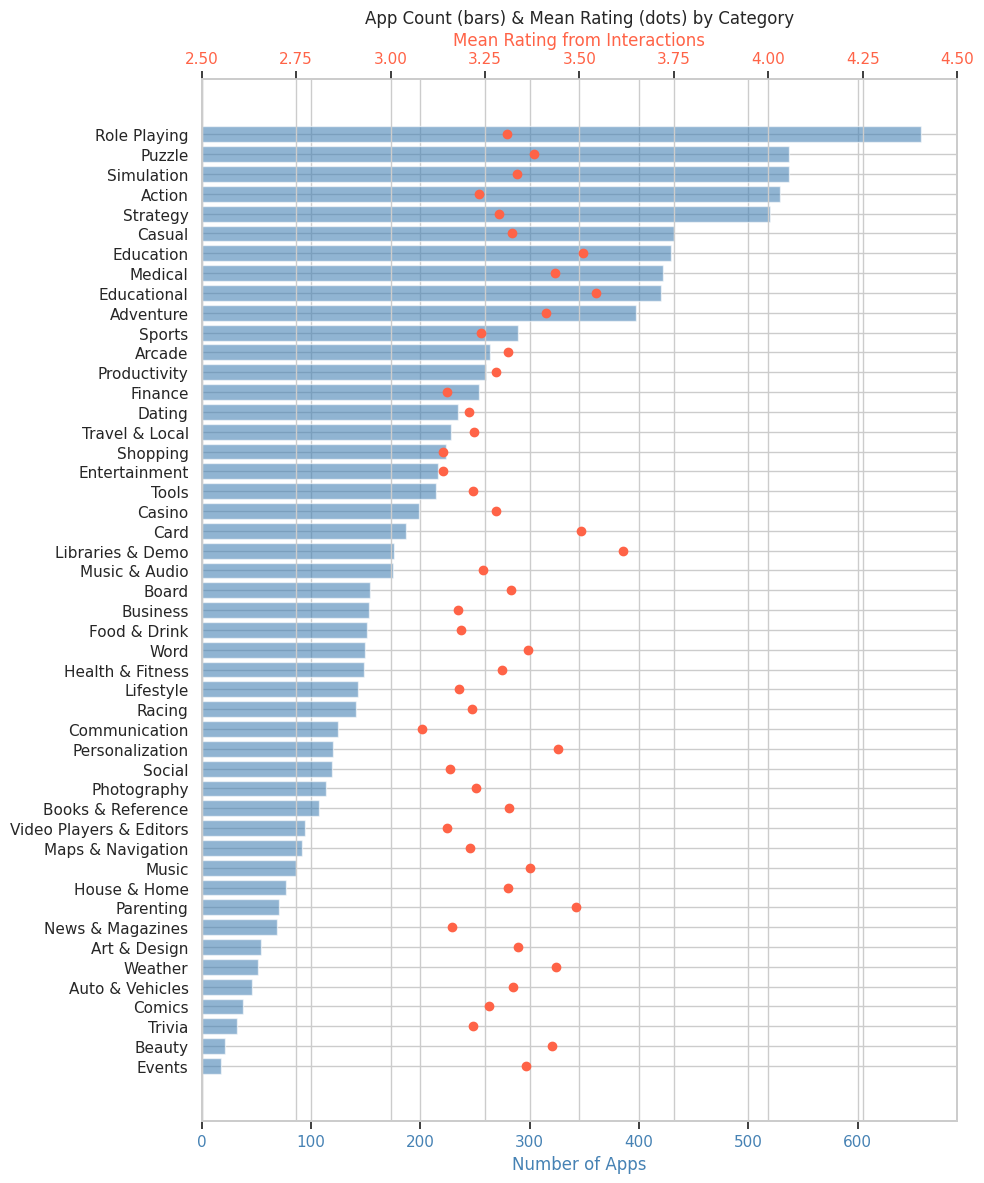

In [ ]:
cat_counts      = meta['app_category'].value_counts().sort_values()
cat_rating_map  = inter_eda.groupby('app_category')['rating'].mean()
ratings_ordered = cat_rating_map.reindex(cat_counts.index)

fig, ax1 = plt.subplots(figsize=(10, 12))
ax1.barh(range(len(cat_counts)), cat_counts.values, color='steelblue', alpha=0.6)
ax1.set_yticks(range(len(cat_counts)))
ax1.set_yticklabels(cat_counts.index)
ax1.set_xlabel('Number of Apps', color='steelblue')
ax1.tick_params(axis='x', labelcolor='steelblue')

ax2 = ax1.twiny()
ax2.plot(ratings_ordered.values, range(len(cat_counts)), 'o', color='tomato', markersize=6)
ax2.set_xlabel('Mean Rating from Interactions', color='tomato')
ax2.tick_params(axis='x', labelcolor='tomato')
ax2.set_xlim(2.5, 4.5)

plt.title('App Count (bars) & Mean Rating (dots) by Category')
plt.tight_layout()
plt.show()

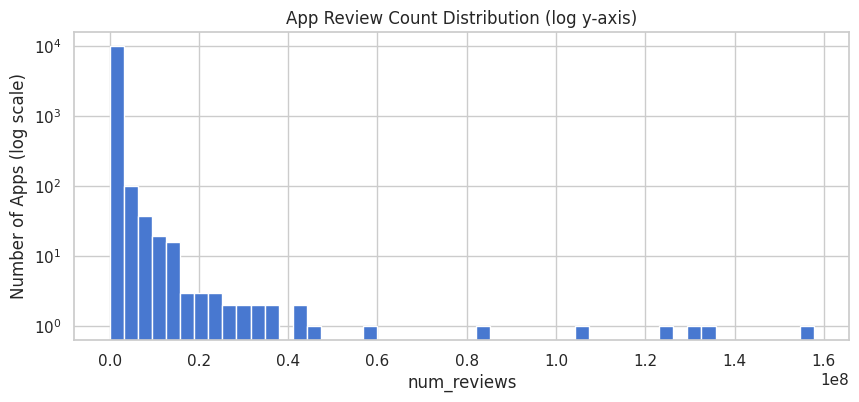

count    1.017300e+04
mean     3.881984e+05
std      3.507690e+06
min      0.000000e+00
25%      2.535000e+03
50%      1.618000e+04
75%      9.533100e+04
max      1.578377e+08
Name: num_reviews, dtype: float64


In [ ]:
meta['num_reviews'].dropna().apply(lambda x: max(x, 1)).hist(bins=50, log=True)
plt.title('App Review Count Distribution (log y-axis)')
plt.xlabel('num_reviews')
plt.ylabel('Number of Apps (log scale)')
plt.show()
print(meta['num_reviews'].describe())

The category breakdown reveals heavy concentration in a small number of dominant categories with a long tail of niche genres. Mean rating varies modestly across categories, suggesting rating inflation is dataset-wide rather than category-specific. The review count distribution follows a severe power law, motivating leave-one-out evaluation over random splits.

##### User Behavior

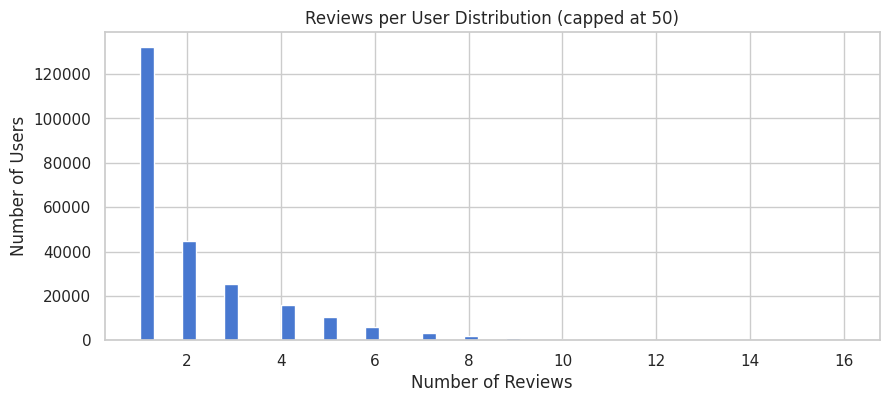

count    241156.000000
mean          2.073347
std           1.625353
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max          16.000000
dtype: float64


In [ ]:
user_counts = inter_eda.groupby('uid').size()
user_counts.clip(upper=50).hist(bins=50)
plt.title('Reviews per User Distribution (capped at 50)')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Users')
plt.show()
print(user_counts.describe())

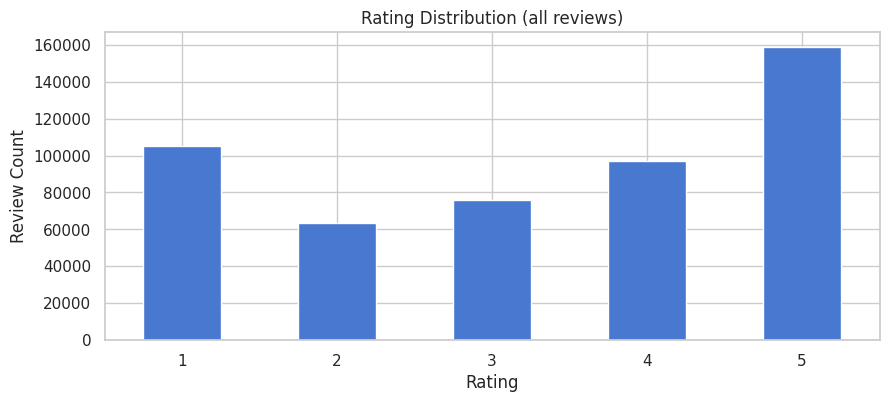

Mean rating: 3.28


In [ ]:
inter_eda['rating'].value_counts().sort_index().plot(
    kind='bar', title='Rating Distribution (all reviews)', rot=0)
plt.xlabel('Rating')
plt.ylabel('Review Count')
plt.show()
print('Mean rating:', inter_eda['rating'].mean().round(2))

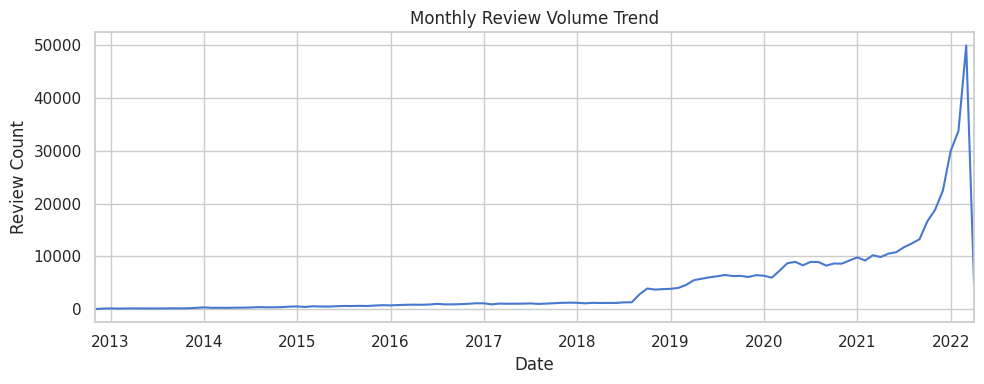

In [ ]:
inter_eda.set_index('formated_date').resample('ME').size().plot(
    title='Monthly Review Volume Trend')
plt.xlabel('Date')
plt.ylabel('Review Count')
plt.tight_layout()
plt.show()

The reviews-per-user distribution is right-skewed. The rating distribution is strongly bimodal with 5-star reviews dominating -- consistent with the app-store J-curve where users review primarily after strongly positive or negative experiences. For sequential recommendation, ratings are better treated as engagement signals than graded preferences. Review volume grows steadily with no visible gaps, confirming temporal coverage suitable for time-aware modelling.

##### Behavioral Drift

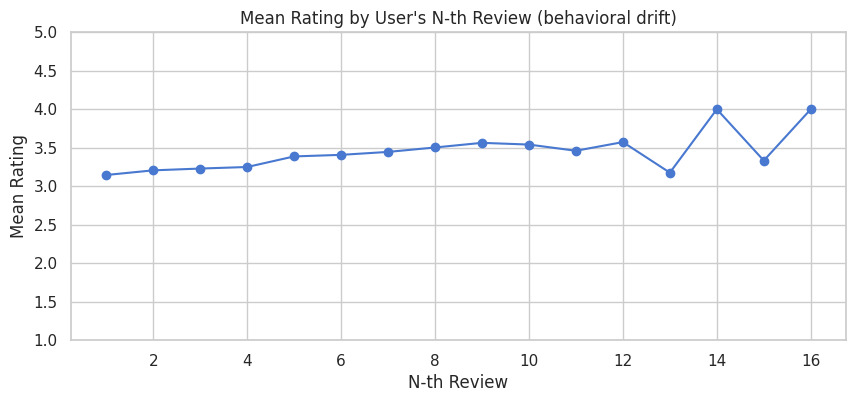

In [ ]:
user_freq = inter_eda.groupby('uid').agg(
    review_count = ('rating', 'count'),
    first_review = ('formated_date', 'min'),
    last_review  = ('formated_date', 'max'),
).reset_index()

active_users = user_freq[user_freq['review_count'] >= 5]['uid']
inter_active = inter_eda[inter_eda['uid'].isin(active_users)].copy()
inter_active = inter_active.sort_values(['uid', 'formated_date'])
inter_active['review_order'] = inter_active.groupby('uid').cumcount() + 1

order_rating = (
    inter_active[inter_active['review_order'] <= 20]
    .groupby('review_order')['rating']
    .mean()
)
order_rating.plot(marker='o', title="Mean Rating by User's N-th Review (behavioral drift)")
plt.xlabel('N-th Review')
plt.ylabel('Mean Rating')
plt.ylim(1, 5)
plt.show()

Mean rating exhibits a systematic trend across sequence positions: user reviewing tendencies are not stationary over time. This temporal non-stationarity is precisely what TiSASRec's time-interval embeddings are designed to capture.

##### User Dimension Analysis

Users who reviewed only 1 category : 55.5%
Users who reviewed 2+ categories   : 44.5%

count    241156.000000
mean          1.994589
std           1.488630
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max          15.000000
Name: n_categories, dtype: float64


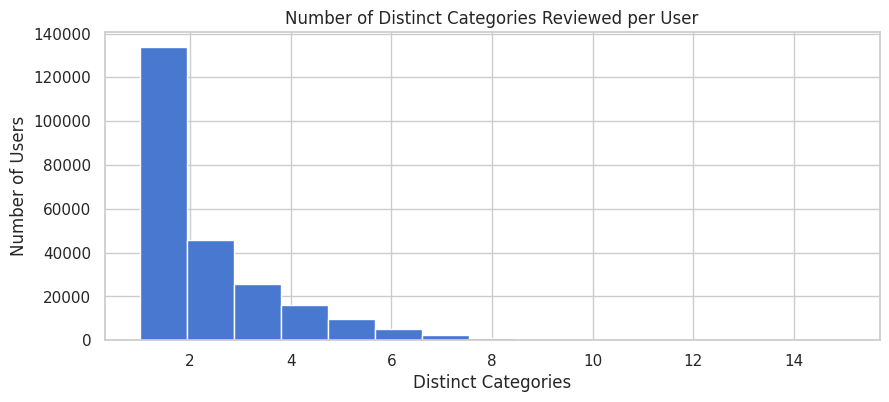

In [ ]:
user_cat = inter_eda.groupby('uid')['app_category'].nunique().rename('n_categories')

single_pct = (user_cat == 1).mean()
print(f'Users who reviewed only 1 category : {single_pct:.1%}')
print(f'Users who reviewed 2+ categories   : {1 - single_pct:.1%}')
print()
print(user_cat.describe())

user_cat.clip(upper=15).hist(bins=15)
plt.title('Number of Distinct Categories Reviewed per User')
plt.xlabel('Distinct Categories')
plt.ylabel('Number of Users')
plt.show()

Users who always give the same rating (std = 0): 59.6%

        user_mean    user_std
count  241156.000  108904.000
mean        3.285       1.348
std         1.290       0.733
min         1.000       0.000
25%         2.333       0.707
50%         3.333       1.414
75%         4.200       1.890
max         5.000       2.828


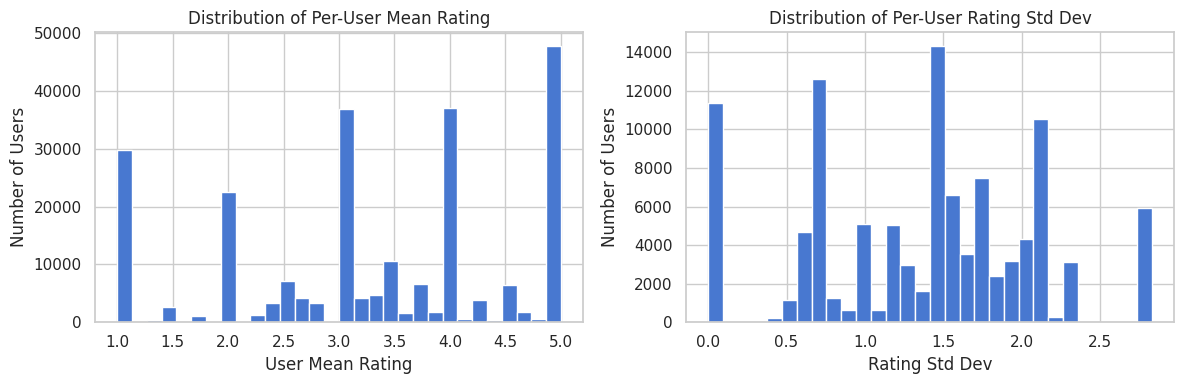

In [ ]:
user_bias = inter_eda.groupby('uid')['rating'].agg(user_mean='mean', user_std='std')

always_same = (user_bias['user_std'].fillna(0) == 0).mean()
print(f'Users who always give the same rating (std = 0): {always_same:.1%}')
print()
print(user_bias.describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
user_bias['user_mean'].hist(bins=30, ax=axes[0])
axes[0].set_title('Distribution of Per-User Mean Rating')
axes[0].set_xlabel('User Mean Rating')
axes[0].set_ylabel('Number of Users')

user_bias['user_std'].dropna().hist(bins=30, ax=axes[1])
axes[1].set_title('Distribution of Per-User Rating Std Dev')
axes[1].set_xlabel('Rating Std Dev')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

A substantial proportion of users confine their reviews to a single category, indicating niche behavior the sequential model implicitly encodes. Rating bias analysis reveals significant user heterogeneity, motivating learned user representations over global statistics.

##### Review Sentiment Analysis

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
DEVICE         = 0
BATCH_SIZE     = 1024
MAX_LEN        = 128
CHECKPOINT_DIR = './sentiment_checkpoints'
MIN_ROWS       = 500_000    # if checkpoints already have this many rows, skip inference

# ── Check existing checkpoints ────────────────────────────────────────────────
ckpt_files = sorted([
    os.path.join(CHECKPOINT_DIR, f)
    for f in os.listdir(CHECKPOINT_DIR)
    if f.endswith('.parquet')
]) if os.path.exists(CHECKPOINT_DIR) else []

if ckpt_files:
    print(f'Found {len(ckpt_files)} checkpoint file(s), loading...')
    sample_df = pd.concat([pd.read_parquet(f) for f in ckpt_files], ignore_index=True)
    print(f'Loaded {len(sample_df):,} rows from checkpoints — skipping inference.')
else:
    # ── Load model in fp16 ────────────────────────────────────────────────────
    MODEL_NAME = 'distilbert-base-uncased-finetuned-sst-2-english'
    tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
    model      = AutoModelForSequenceClassification.from_pretrained(
                    MODEL_NAME, torch_dtype=torch.float16
                ).to(DEVICE).eval()

    LABEL_MAP = {0: 'NEGATIVE', 1: 'POSITIVE'}

    def run_sentiment(texts: list) -> list:
        enc = tokenizer(texts, truncation=True, max_length=MAX_LEN,
                        padding=True, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            logits = model(**enc).logits
        probs  = torch.softmax(logits, dim=-1).cpu().float().numpy()
        labels = probs.argmax(axis=1)
        return [
            {'label': LABEL_MAP[int(l)], 'score': float(probs[i, int(l)])}
            for i, l in enumerate(labels)
        ]

    # ── Stratified sample ─────────────────────────────────────────────────────
    sample_df_input = (
        inter[inter['review'].notna()]
        .groupby('rating', group_keys=False)
        .apply(lambda x: x.sample(min(len(x), 200_000), random_state=42))
        .reset_index(drop=True)
    )
    print(f'Sampled {len(sample_df_input):,} reviews for sentiment analysis')

    texts = sample_df_input['review'].tolist()
    preds = []
    for i in range(0, len(texts), BATCH_SIZE):
        preds.extend(run_sentiment(texts[i:i + BATCH_SIZE]))
        if i % 50_000 == 0:
            print(f'  {i:,} / {len(texts):,} done')

    sample_df_input['sentiment']        = [r['label'] for r in preds]
    sample_df_input['sentiment_score']  = [r['score'] for r in preds]
    sample_df_input['sentiment_signed'] = np.where(
        sample_df_input['sentiment'] == 'POSITIVE',
        sample_df_input['sentiment_score'],
        -sample_df_input['sentiment_score']
    )
    sample_df = sample_df_input
    del preds
    gc.collect()

print(f'\nTotal reviews with sentiment: {len(sample_df):,}')
print(sample_df['sentiment'].value_counts())
print(f"\nMean signed score: {sample_df['sentiment_signed'].mean():.3f}")

Found 23 checkpoint file(s), loading...
Loaded 2,299,857 rows from checkpoints — skipping inference.

Total reviews with sentiment: 2,299,857
sentiment
NEGATIVE    1152622
POSITIVE    1147235
Name: count, dtype: int64

Mean signed score: 0.002


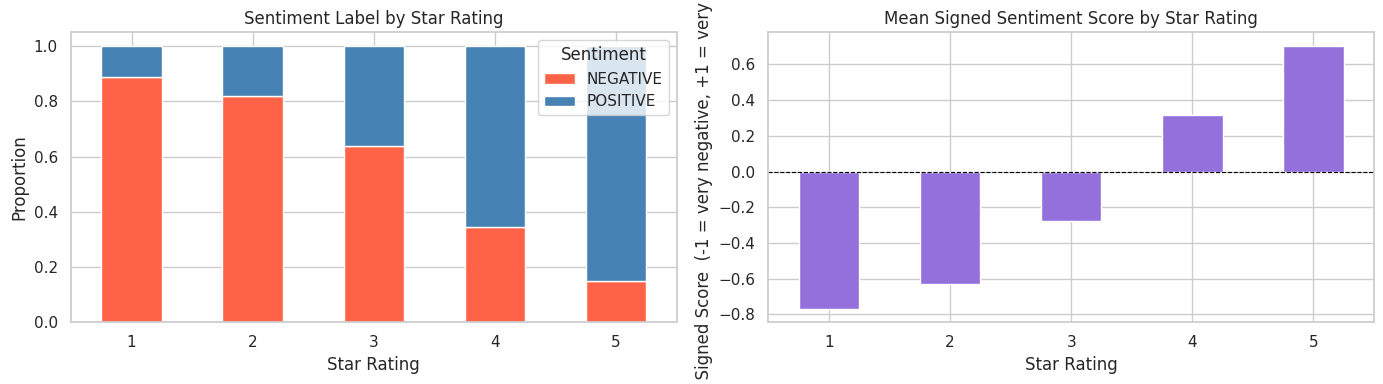

High-star (4-5) but NEGATIVE sentiment : 262,273  (11.4%)
Low-star  (1-2) but POSITIVE sentiment : 107,144  (4.7%)
Overall mismatch rate                  : 16.1%


In [ ]:
# ── Sentiment label proportion by star rating ─────────────────────────────────
sentiment_by_rating = (
    sample_df.groupby(['rating', 'sentiment'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum(), axis=1)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sentiment_by_rating.plot(kind='bar', stacked=True, ax=axes[0],
                          title='Sentiment Label by Star Rating', rot=0,
                          color=['tomato', 'steelblue'])
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Sentiment')

# ── Mean signed sentiment score by star rating ────────────────────────────────
mean_score = sample_df.groupby('rating')['sentiment_signed'].mean()
mean_score.plot(kind='bar', ax=axes[1], color='mediumpurple', rot=0,
                title='Mean Signed Sentiment Score by Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Mean Signed Score  (-1 = very negative, +1 = very positive)')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

# ── Mismatch summary ──────────────────────────────────────────────────────────
high_star_neg = sample_df[(sample_df['rating'] >= 4) & (sample_df['sentiment'] == 'NEGATIVE')]
low_star_pos  = sample_df[(sample_df['rating'] <= 2) & (sample_df['sentiment'] == 'POSITIVE')]
total         = len(sample_df)

print(f'High-star (4-5) but NEGATIVE sentiment : {len(high_star_neg):,}  ({len(high_star_neg)/total:.1%})')
print(f'Low-star  (1-2) but POSITIVE sentiment : {len(low_star_pos):,}  ({len(low_star_pos)/total:.1%})')
print(f'Overall mismatch rate                  : {(len(high_star_neg)+len(low_star_pos))/total:.1%}')

Positive sentiment proportions rise monotonically with star rating. The mismatch rate peaks at 3 stars and is lowest at the extremes, validating star rating as a reliable proxy for user sentiment and an appropriate interaction signal.

#### 2.1.3 Data Preprocessing

The baseline data pipeline has two stages: first download the raw MobileRec CSV files with the Hugging Face CLI, then run the preprocessing command that converts them into sequence artifacts.

```bash
source .venv/bin/activate
hf download recmeapp/mobilerec interactions/mobilerec_final.csv app_meta/app_meta.csv \
  --repo-type dataset \
  --local-dir data/raw/mobilerec
prepare-mobilerec
```

The preprocessing script `main/models/prepare_mobilerec.py` implements this transformation with **DuckDB** rather than loading the entire interactions table into memory. The script resolves the raw files, applies a configurable memory cap (`2GB` by default), and reads only the fields required for recommendation: user id, app id, category, rating, votes, and timestamp information.

The preprocessing logic is chronological and recommendation-oriented:

- invalid rows are dropped if `uid`, `app_package`, or usable time information is missing
- the interaction timestamp is taken from `unix_timestamp` when available, otherwise parsed from `formated_date`
- low-activity users are removed using a minimum-history threshold of 5 interactions
- users can be deterministically subsampled for smoke tests with `--sample-users`
- remaining users and apps are mapped to contiguous integer ids with `ROW_NUMBER()`
- each user's history is sorted by `(timestamp, app_package)` and assigned a sequence position

After cleaning and encoding, the script writes both interaction-level and sequence-level parquet files. The sequence table is built for chronological leave-one-out evaluation, with `train_sequence`, `validation_sequence`, `test_sequence`, `validation_target`, and `test_target` columns. This is the key handoff between raw review data and the SASRec trainer: once the parquet artifacts are created, the learning problem becomes pure next-item prediction over ordered item-id sequences.

The preprocessing stage also writes `user_mapping.parquet`, `item_mapping.parquet`, `app_metadata.parquet`, and `summary.json`, so it is not just a cleaning step but a full reproducible contract between data ingestion and model training.

While the pre-processed dataset was good to go, we had to modify and transform certain columns to well-adjust to our requirements of TiSASRec-M training. The [`mobilerec_eda_etl.ipynb`](./main/mobilerec_eda_etl.ipynb) is the MobileRec data-prep notebook for the project. It inspects processed parquet files, builds a category mapping, enriches sequence and interaction tables, then stages Kaggle-ready final aliases.

- The notebook starts from `processed` folder, lists parquet artifacts, and records the current local outputs: `48` category rows, `19,297,019` enriched interaction rows, and `700,111` enriched sequence rows.

- It derives `app_category_mapping.parquet` from `app_metadata.parquet` by counting unique `app_category` values, sorting them, assigning dense `app_category_id` values, and saving the mapping.

- It enriches sequences from `sequences.parquet`, `item_mapping.parquet`, `app_metadata.parquet`, and `app_category_mapping.parquet`. The cell keeps a smoke-test knob, renames `votes` to `review_upvotes`, binarizes ratings [from a scale of 0 - 5, to {-1,1}], and attaches category, review-count, average-rating, and price arrays.

- It enriches interactions from `interactions.parquet` by dropping raw app/package fields, renaming `votes`, binarizing ratings, mapping categories, and writing `enriched_mobilerec_interactions.parquet`.

<small>_`Key assumption: We have set the threshold barrier to mark anything >= 3 star-review as a positive signal, else negative`_</small>

- Its publish cell stages original processed files, enriched files, and `final_*` aliases. `final_app_category.parquet` points to the category mapping, `final_item_mapping.parquet` points to item mapping, and `final_sequences.parquet` points to enriched sequences.

- The sanity-check section downloads the Kaggle snapshot with retries, then verifies key row counts: `19,297,019` interaction rows, `700,111` sequence rows, `48` final category rows, `10,173` final item rows, and `700,111` final sequence rows.

**The final processed dataset can be found in Kaggle: [https://www.kaggle.com/datasets/gitaalekhyapaul/cs5242-mobilerec-dataset](https://www.kaggle.com/datasets/gitaalekhyapaul/cs5242-mobilerec-dataset)**

---
### 2.2 Steam Dataset

#### 2.2.1 Dataset Description

In order to test the transfer evaluation for cross-domain tasks, we decided to create our own data scraper and index a comparable dataset, like the game reviews activity on Steam. SteamRec is a project-built Steam review dataset for PC game recommendation. It starts from Steam app metadata and review endpoints, then keeps a bounded sample of active games. The processed snapshot contains `9,598` sampled apps and `4,798,710` raw review rows.

Each raw review stores a timestamp, Steam user id, Steam app id, unique review id, binary review score, and review upvote count. The raw review signal uses **`1`** for recommended reviews and **`-1`** for not recommended reviews. The raw table spans reviews from `15 June 2011` to `23 April 2026`.

The app metadata table stores the original Steam app id, total recommendation count, positive-review percentage, price, and Steam genre ids. The dataset has `17` genre labels in the current processed output. The largest groups are Indie with `5,837` apps, Action with `4,416` apps, Adventure with `4,327` apps, Simulation with `2,739` apps, and RPG with `2,655` apps.

SteamRec is a sample, not a full Steam mirror. We limited the crawl to high-activity games and capped review rows per app. This kept the dataset feasible to collect through public endpoints and still produced a sufficiently large user-item graph for sequential recommendation.

**The crawled dataset is publicly available at: [https://www.kaggle.com/datasets/gitaalekhyapaul/steam-cs5242-dataset](https://www.kaggle.com/datasets/gitaalekhyapaul/steam-cs5242-dataset)**

#### 2.2.2 Collection Pipeline

##### **Pipeline Description and Methodology**
The Steam crawler uses five cacheable stages. `Stage 1` collects the Steam app list. `Stage 2` fetches `appdetails` for each app. `Stage 3` merges catalog rows with app metadata and marks eligible games based on the review threshold criteria (for our project it is set to minimum 500 reviews per game). `Stage 4` samples eligible games with a fixed seed. `Stage 5` fetches reviews for the sampled games. The stage layout is documented in detail in the [README.md:50](./steam-crawler/README.md:50).

Since the crawling needed a lot of time to finish, and we were already running some jobs in the compute cluster, we had to patch some stages to match the SteamRec with the existing MobileRec dataset. For that reason, `Stage 4a` enriches the sampled games with price, positive-review percentage, and Steam genres. Source: [stage4a.py:360](./steam-crawler/src/steam_crawler/stage4a.py:360).

`Stage 5a` converts raw review JSON into a narrow review table. It reads `timestamp_created`, `author.steamid`, `recommendationid`, `voted_up`, and `votes_up`. It maps `voted_up=True` to `1` and `voted_up=False` to `-1`. Source: [stage5a.py:138](./steam-crawler/src/steam_crawler/stage5a.py:138).

The review collection logic takes recent reviews first, then fills any remaining quota with helpful-ranked reviews. The relevant code starts at [pipeline.py:421](./steam-crawler/src/steam_crawler/pipeline.py:421) and continues through [pipeline.py:456](./steam-crawler/src/steam_crawler/pipeline.py:456). In this run, nearly all games reached the cap through recent reviews, so the raw stream split is `4,798,210` recent rows and `500` helpful rows.

The final dataset consist of reviews from high-signal games [>= 500 reviews] and pro-active users [>= 5 reviews] and is a decent representative of the MobileRec comparable. 

```bash
Total reviews: 4,798,710
Total unique users: 2,927,350
Users with at least 5 reviews: 118,048 / 2,927,350
Filtered reviews kept for downstream ETL: 1,223,891
```
##### **The stage funnel can be seen in the diagram below:**

![Stage Funnel](./steam-crawler/report/steamrec_stage_funnel.png)

##### **Challenges faced and solutions**
The crawl exposed three blockers. The main blocker was access, not parsing. Steam throttled repeated store requests at roughly **200 requests per 5 minutes**. The `429` responses often lacked `Retry-After` or `X-Retry-After`, so the retry interval required a lot of trial and error with frequent checkpoints, it is for that reason the crawler recorded full headers and used a `300` second cooling gap before retry. The backoff was exponential with a base of `2`.

The second blocker was cluster egress. The SoC compute cluster could not reach **`store.steampowered.com/api`**. We routed cluster traffic through our own proxy (written purely in the NGINX config, hence there is no code in the repository) [`https://gpaul.cc/steamstore`](https://gpaul.cc/steamstore), with direct Steam hosts kept for local runs. 

The third blocker was restart cost. A full scrape can run for many hours. Stage 2 writes each successful `appdetails` response immediately. Stage 5 flushes review rows and cursor progress after each fetched page. This turned failed cluster jobs into resumable runs. The resume methodology is documented at [README.md:680](./steam-crawler/README.md:680).

These blockers shaped the final design. The crawler has **`explicit endpoint modes`**, **`conservative retry behavior`**, **`per-stage logs`**, and **`resumable output`** files. This is why the project could not collect the entire Steam dataset, but the learnings taught us how to make a controlled data build, not simply a public dataset download. The SteamRec collection was a dataset engineering exercise, not a simple download. The final dataset exists through bounded sampling, fixed cooldown behavior, proxy routing, staged checkpointing, and Kaggle publication.

#### 2.2.3 Exploratory Data Analysis

#### 2.2.4 Data Preprocessing

---
## 3. Methodology

### 3.1 Problem Formulation

For each user $u$, we construct a chronologically ordered item sequence $S_u = [i_1, i_2, \ldots, i_T]$ from their review history after preprocessing. Given a prefix $[i_1, \ldots, i_t]$, the task is to rank the ground-truth next item $i_{t+1}$ above other candidate items in the catalog.

In the baseline setting, every observed interaction is treated as an implicit positive event. The model does not predict ratings or review text; it predicts **which app comes next**. The data split follows chronological leave-one-out evaluation:

- training uses all but the last two items in a user's sequence
- validation predicts the second-last item from the training prefix
- test predicts the last item from the validation prefix

Let $f_\theta(S_u^{(t)}, j)$ denote the score assigned by the model to candidate item $j$ given the observed prefix $S_u^{(t)}$. At evaluation time, items are ranked by this score, and we report **HR@10** and **NDCG@10**. HR@10 measures whether the true next item appears in the top 10, while NDCG@10 further rewards higher ranks inside that top-10 window.

This formulation matches the standard sequential recommendation protocol used by SASRec and provides a clean baseline before introducing explicit time-interval modeling in TiSASRec.

### 3.2 SASRec (Baseline)

We use **SASRec** as the primary baseline because it isolates the contribution of sequence order. Conceptually, SASRec takes a padded item-id sequence as input, embeds each item, adds a positional embedding, and applies a stack of causal self-attention blocks so that the hidden state at position $t$ can attend only to positions $\le t$.

In our report, the baseline should be understood as an **item-sequence model**: it answers the question "how far can we get using order alone?" This is important because MobileRec also contains timestamps, categories, ratings, votes, and app metadata. By starting with SASRec, we establish a point of comparison for later time-aware variants.

At a high level, the model computes

$$
H^{(0)} = E_{item}(S) + E_{pos}, \qquad H^{(l)} = \mathrm{SASRecBlock}^{(l)}(H^{(l-1)}),
$$

and uses the final hidden state at the last non-padding position as the user representation for ranking. Candidate items are scored by dot product with the shared item embedding table.

The training objective is pointwise binary classification over next-item pairs: the observed next item is treated as a positive target, and a sampled unseen item is treated as a negative target. In the training code, `training_logits(...)` returns positive and negative logits and the loss is computed with `BCEWithLogitsLoss`.

Although the unified trainer in `main/train_model.py` also supports time matrices and metadata tensors for TiSASRec variants, the `SASRec` class in `main/models/sasrec.py` ignores those extra inputs. This separation is useful: the experimental pipeline can stay shared while the baseline model itself remains a clean sequential-attention encoder.

#### SASRec Architecture In The Repository

`main/models/sasrec.py` reveals several implementation details that matter for interpreting the baseline:

- **Embedding layer**: `item_embedding` has size `num_items + 1`, where index `0` is reserved for padding; the padding embedding is explicitly zeroed out.
- **Positional encoding**: `position_embedding(max_len, hidden_size)` is added to the scaled item embeddings, so the model knows whether an item appeared early or late in the truncated sequence.
- **Causal masking**: each `SASRecBlock` builds an upper-triangular Boolean mask, preventing attention from looking into the future.
- **Pre-layer normalization**: attention is applied to a normalized input (`attn_norm`) before the residual connection, which generally stabilizes Transformer training.
- **Feed-forward sublayer**: the pointwise MLP expands the hidden dimension by a factor of 4, applies `GELU`, then projects back to the original size with dropout on both linear layers.
- **Padding control**: after each block, padded positions are zeroed with `masked_fill`, so they do not contaminate later representations.
- **Final user representation**: `user_representation(...)` selects the hidden state at the last non-padding index rather than averaging over the sequence.
- **Weight tying for ranking**: positive, negative, sampled-candidate, and full-catalog scores are all produced with the same item embedding matrix, making the output layer parameter-efficient and consistent across training and evaluation.

This design closely matches the spirit of the original SASRec paper: it is lightweight, autoregressive, and optimized for ranking the next item rather than reconstructing the entire sequence.

### 3.3 TiSASRec (Proposed)

---
## 4. Experiments

### 4.1 Experimental Setup

The baseline experiment follows a reproducible two-stage workflow: prepare MobileRec into sequential parquet artifacts, then train SASRec on those artifacts. The commands are:

```bash
source .venv/bin/activate
hf download recmeapp/mobilerec interactions/mobilerec_final.csv app_meta/app_meta.csv \
  --repo-type dataset \
  --local-dir data/raw/mobilerec
prepare-mobilerec
train-sasrec \
  --data-dir data/processed/mobilerec \
  --output-dir data/outputs/sasrec-baseline-formal \
  --epochs 5 \
  --batch-size 256 \
  --max-len 50 \
  --eval-negative-samples 100 \
  --report-full-eval \
  --seed 42
```

For the formal MobileRec baseline stored at `data/outputs/sasrec-baseline-formal/metrics.json`, the run configuration is:

- epochs: 5
- batch size: 256
- maximum sequence length: 50
- hidden size: 128
- transformer blocks: 2
- attention heads: 2
- dropout: 0.2
- learning rate: 0.001
- weight decay: 1e-5
- random seed: 42

The evaluation protocol combines two views of ranking quality:

- validation and test use sampled ranking with 100 negatives per user
- negatives exclude items already present in the input sequence
- the best checkpoint is chosen by validation `HR@10`
- a separate full-ranking test pass evaluates against the whole candidate catalog except padding and seen items

This distinction matters when interpreting results: sampled metrics are useful for fast iteration during training, whereas full-ranking metrics are stricter because the target must outrank the entire catalog rather than only 100 sampled distractors.

### 4.2 Results - MobileRec

| Model | Sampled HR@10 | Sampled NDCG@10 | Full HR@10 | Full NDCG@10 |
|---|---|---|---|---|
| SASRec | 0.2953 | 0.1605 | 0.00845 | 0.00385 |
| TiSASRec | -- | -- | -- | -- |

These results establish a clear SASRec baseline: the model performs reasonably under sampled evaluation, but the full-ranking results are much lower, indicating that next-item retrieval is substantially harder when the model must rank against the entire app catalog.

#### Baseline Readout

The training history in `metrics.json` also shows steady validation improvement across 5 epochs, with `best_val_hr_at_10 = 0.2383` reached at the final epoch. This suggests the model did not collapse or overfit catastrophically in the baseline run; instead, it produced a stable reference point that later TiSASRec variants should exceed under the same evaluation protocol.

### 4.3 Results - Steam

| Model | HR@10 | NDCG@10 |
|---|---|---|
| SASRec | -- | -- |
| TiSASRec | -- | -- |

### 4.4 Analysis & Discussion

---
## 5. Conclusion

---
## References

- Kang, W., & McAuley, J. (2018). **Self-Attentive Sequential Recommendation**. *ICDM 2018*.
- Li, J., Wang, Y., & McAuley, J. (2020). **Time Interval Aware Self-Attention for Sequential Recommendation**. *WSDM 2020*.
- MobileRec Dataset: https://huggingface.co/datasets/recmeapp/mobilerec
- Steam Platform: https://store.steampowered.com